<a href="https://colab.research.google.com/github/kimve1969/mgu_ds_cours/blob/main/semestr%202.2/task%201/bank_marketing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ВМК МГУ, Курс по Data Science (DS) и Machine Learning (ML) 2026 год
2 семестр, Методы машинного обучения, \
Задание 1, Маркейтинговая компания банка \
Ким Виталий Евгеньевич, ПАО "Сургутнефтегаз" \
11.05.2026

# Постановка задачи
Набор данных содержит информацию о клиентах банка и предыдущей маркетинговой кампании банка. Банк хочет повысить свой депозитный портфель путем предложения предыдущим клиентам срочного вклада. На входе мы имеем профиль клиента, которому уже предлагался вклад и каков был результат предложения: сделал или не сделал вклад. Цель заключается в том, чтобы предсказать, откликнется ли клиент на предложение банка по срочному вкладу или нет. Желательно минимизировать количество предложений вклада, которые заведомо не будут приняты клиентом так как это повышает расходы на маркетинг кроме того большое количество неэффективных предложений может привести к репутационным потерям банка.

Описание параметров файла:
https://archive.ics.uci.edu/dataset/222/bank+marketing

# Описание классификаторов (кратко)

1. LinearDiscriminantAnalysis (LDA)
Линейный алгоритм, который ищет гиперплоскость, максимально разделяющую классы. Предполагает, что данные каждого класса имеют нормальное распределение с одинаковой ковариационной матрицей. Разделяющая граница между классами — прямая линия/плоскость.

2. QuadraticDiscriminantAnalysis (QDA)
Расширение LDA, где для каждого класса своя ковариационная матрица. Разделяющая граница — квадратичная поверхность (парабола, гипербола). Работает лучше, когда разброс данных в классах сильно отличается.

3. KNeighborsClassifier (KNN)
«Ленивый» алгоритм, не строит модель на этапе обучения. Предсказание для нового объекта — выбор класса среди k ближайших соседей из обучающей выборки (для бинарной классификации обычно выбирается нечетное кол-во соседей). Близость определяется метрикой (обычно евклидово расстояние).

4. LogisticRegression
Линейный классификатор, который моделирует вероятность принадлежности классу через логистическую (сигмоидную) функцию. Обучается методом максимума правдоподобия. Выдаёт вероятности от 0 до 1.

5. GaussianNB (Наивный Байесовский классификатор)
Байесовский метод с «наивным» предположением о независимости признаков при условии класса. Для каждого признака предполагается гауссовское (нормальное) распределение. Простой, быстрый, мало подвержен переобучению.

# Выполнение задания
Считываем файл (расположен на github) с данными \
показываем первые 5 строк

In [2]:
import pandas as pd

try:
    df_csv = pd.read_csv('https://raw.githubusercontent.com/kimve1969/mgu_ds_cours/refs/heads/main/semestr%202.2/task%201/bank-full.csv', sep=';')
    print("Первые 5 строк CSV-файла:")
    print(df_csv.head())
except FileNotFoundError:
    print("CSV-файл 'bank-full.csv' не найден. Убедитесь, что файл загружен и имя указано верно.")

Первые 5 строк CSV-файла:
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  


Выводим статитику по данным в файле (нулевые, пропущенные, мин, макс и т.д)

In [3]:
print("\nИнформация о DataFrame:")
df_csv.info()

print("\nПроверка на пропущенные значения:")
print(df_csv.isnull().sum())

print("\nОписательная статистика для числовых столбцов:")
print(df_csv.describe())

print("\nКоличество уникальных значений для некоторых категориальных столбцов:")
for col in ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']:
      print(f"\n{col}:", df_csv[col].value_counts())


Информация о DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB

Проверка на пропущенные значения:
age          0
job          0
marital  

Выводим анализ попарной линейной корреляции между числовыми столбцами для выявления коллинеарности. Есть небольшая зависимость между pdays (кол-во дней от предыдущей маркейтинговой компании с клиентом) и previous (кол-во контактов установленных с клиентов до этой маркейтинговой компании), что логично - были контакты, значит были кол-во дней (поэтому возможно один из этих параметров можно удалить из обучения модели)

In [4]:
from pandas.core.arrays import numeric
# Выбираем только числовые столбцы для расчета матрицы корреляции
numerical_cols = df_csv.select_dtypes(include=['int64', 'float64']).columns

print("\nМатрица корреляции для числовых столбцов:")
correlation_matrix = df_csv[numerical_cols].corr()
display(correlation_matrix)


Матрица корреляции для числовых столбцов:


,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.097783,-0.009120,-0.004648,0.004760,-0.023758,0.001288
balance,0.097783,1.000000,0.004503,0.021560,-0.014578,0.003435,0.016674
day,-0.009120,0.004503,1.000000,-0.030206,0.162490,-0.093044,-0.051710
duration,-0.004648,0.021560,-0.030206,1.000000,-0.084570,-0.001565,0.001203
campaign,0.004760,-0.014578,0.162490,-0.084570,1.000000,-0.088628,-0.032855
pdays,-0.023758,0.003435,-0.093044,-0.001565,-0.088628,1.000000,0.454820
previous,0.001288,0.016674,-0.051710,0.001203,-0.032855,0.454820,1.000000


Для наглядности строим тепловую карту попарной коллинеарности

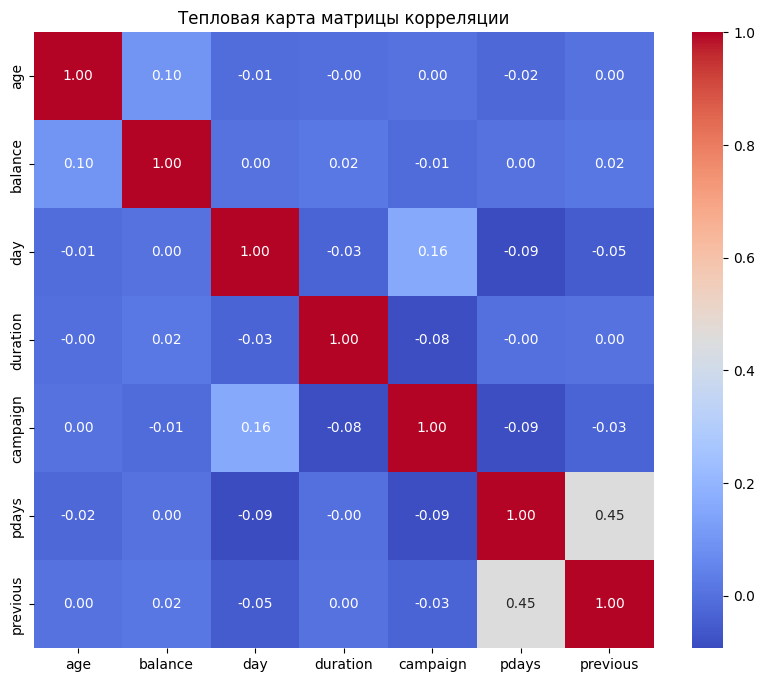

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Тепловая карта матрицы корреляции')
plt.show()

Также строим графики поапрной зависимости

Построение pairplot для ключевых параметров...


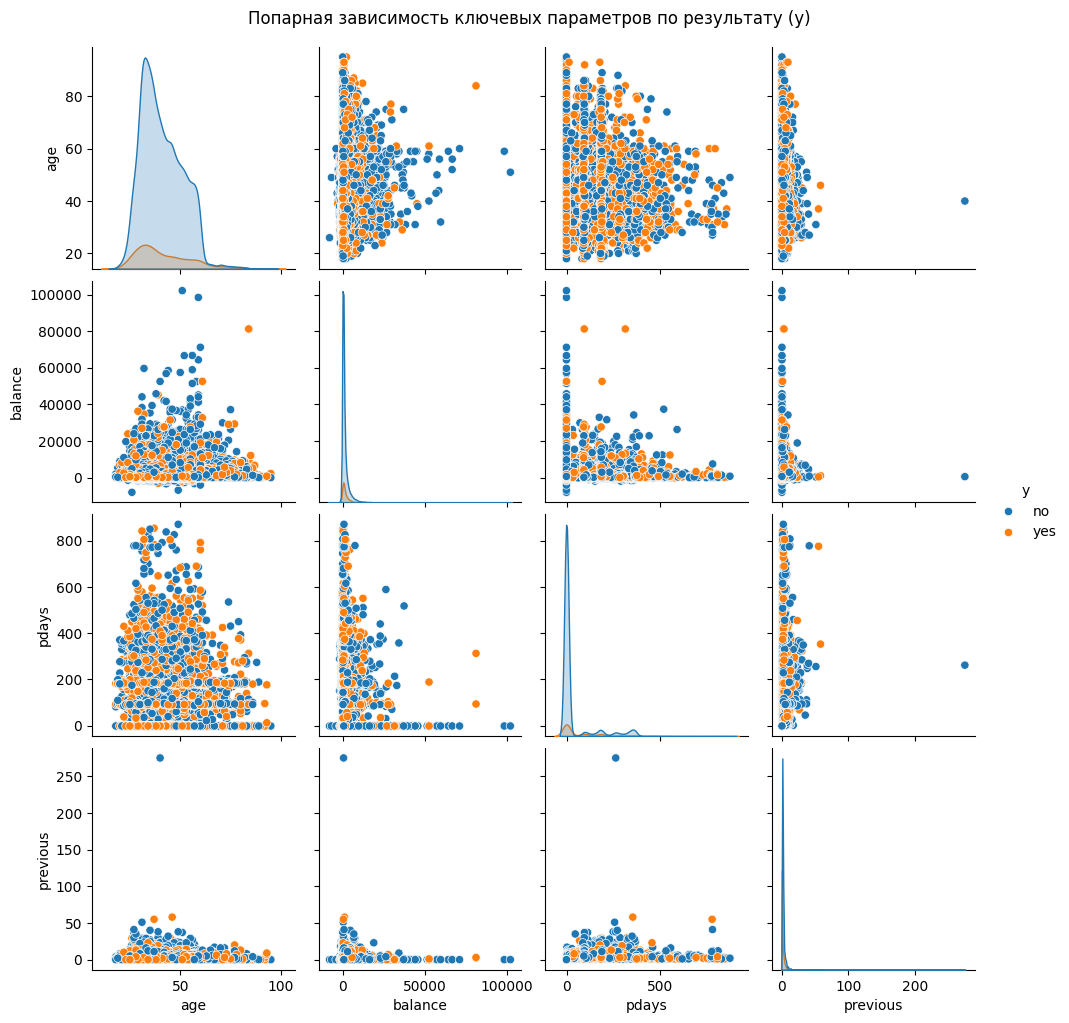

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Выбираем несколько ключевых числовых столбцов и целевую переменную 'y'
# в том числе столбы 'pdays', 'previos' которые имеют корреляцию 0.45 между собой
selected_columns = ['age', 'balance', 'pdays', 'previous', 'y']

# Строим pairplot для выбранных столбцов, используя 'y' для цветовой индикации
print("Построение pairplot для ключевых параметров...")

sns.pairplot(df_csv[selected_columns], diag_kind='kde', hue='y')
plt.suptitle('Попарная зависимость ключевых параметров по результату (y)', y=1.02) # Общий заголовок для графиков
plt.show()

### Подготовка данных для моделирования. Разделяем данные и разметку (y)

In [7]:
# Разделение признаков (X) и целевой переменной (y)
X = df_csv.drop('y', axis=1)
y = df_csv['y']

# Кодирование целевой переменной 'y' (yes/no в 1/0)
y = y.map({'yes': 1, 'no': 0})

print("Размерность df_csv:", df_csv.shape)
print("Размерность X:", X.shape)
print("Размерность y:", y.shape)

Размерность df_csv: (45211, 17)
Размерность X: (45211, 16)
Размерность y: (45211,)


### One-Hot Encoding для категориальных признаков

In [8]:
X_encoded = pd.get_dummies(X, drop_first=True)

print("Размерность X после One-Hot Encoding:", X_encoded.shape)
display(X_encoded.head())

Размерность X после One-Hot Encoding: (45211, 42)


,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,58,2143,5,261,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
1,44,29,5,151,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,33,2,5,76,1,-1,0,False,True,False,...,False,False,False,True,False,False,False,False,False,True
3,47,1506,5,92,1,-1,0,True,False,False,...,False,False,False,True,False,False,False,False,False,True
4,33,1,5,198,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True


### Разделение данных на обучающую и тестовую выборки

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42, stratify=y)

print("Размерность обучающей выборки X_train:", X_train.shape)
print("Размерность тестовой выборки X_test:", X_test.shape)
print("Размерность обучающей выборки y_train:", y_train.shape)
print("Размерность тестовой выборки y_test:", y_test.shape)

print("\nРаспределение целевой переменной в обучающей выборке:\n", y_train.value_counts(normalize=True))
print("\nРаспределение целевой переменной в тестовой выборке:\n", y_test.value_counts(normalize=True))

Размерность обучающей выборки X_train: (31647, 42)
Размерность тестовой выборки X_test: (13564, 42)
Размерность обучающей выборки y_train: (31647,)
Размерность тестовой выборки y_test: (13564,)

Распределение целевой переменной в обучающей выборке:
 y
0    0.883022
1    0.116978
Name: proportion, dtype: float64

Распределение целевой переменной в тестовой выборке:
 y
0    0.882999
1    0.117001
Name: proportion, dtype: float64


### Обучение и сравнение моделей

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import pandas as pd

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    #print(f"\n--- {model_name} ---")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    #y_pred_proba = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    #f1 = f1_score(y_test, y_pred)
    #roc_auc = roc_auc_score(y_test, y_pred_proba)

    #print(f"Accuracy: {accuracy:.4f}")
    #print(f"Precision: {precision:.4f}")
    #print(f"Recall: {recall:.4f}")
    #print(f"F1-Score: {f1:.4f}")
    #print(f"ROC AUC: {roc_auc:.4f}")
    #print("Матрица ошибок:\n", confusion_matrix(y_test, y_pred))
    #print("Отчет по классификации:\n", classification_report(y_test, y_pred))

    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall#,
        #'F1-Score': f1,
        #'ROC AUC': roc_auc
    }

In [11]:
#from numpy import disp
def evaluate_models_batch(X_train, y_train, X_test, y_test):
  # Инициализация моделей
  log_model = LogisticRegression(max_iter=1000) # задаем макс. итер. 1000
  lda_model = LinearDiscriminantAnalysis()
  qda_model = QuadraticDiscriminantAnalysis()
  knn_model = KNeighborsClassifier(n_neighbors=5) # Можно настроить n_neighbors
  gnb_model = GaussianNB()

  # Список для хранения результатов
  results = []

  # Оценка других моделей
  results.append(evaluate_model(log_model, X_train, y_train, X_test, y_test, 'Logistic Regression'))
  results.append(evaluate_model(lda_model, X_train, y_train, X_test, y_test, 'Linear Discriminant Analysis'))
  results.append(evaluate_model(qda_model, X_train, y_train, X_test, y_test, 'Quadratic Discriminant Analysis'))
  results.append(evaluate_model(knn_model, X_train, y_train, X_test, y_test, 'KNeighbors Classifier'))
  results.append(evaluate_model(gnb_model, X_train, y_train, X_test, y_test, 'Gaussian Naive Bayes'))

  # Создание DataFrame для сравнения
  results_df = pd.DataFrame(results)
  display(results_df.set_index('Model'))
  return results_df

### Результаты моделей без нормализации признаков

In [12]:
# запуск пакетной процедуры на все виды моделей на не нормализованных данных
result_befor_norm = evaluate_models_batch(X_train, y_train, X_test, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Accuracy,Precision,Recall
Model,,,
Logistic Regression,0.899808,0.646154,0.317580
Linear Discriminant Analysis,0.901357,0.611062,0.431632
Quadratic Discriminant Analysis,0.869434,0.447066,0.489603
KNeighbors Classifier,0.880198,0.479258,0.276623
Gaussian Naive Bayes,0.863683,0.429947,0.506616


### Результаты моделей с нормализацией признаков

In [13]:
from sklearn.preprocessing import StandardScaler

# Определяем числовые столбцы для масштабирования
numeric_cols = X_encoded.select_dtypes(include=['int64', 'float64']).columns

# Инициализация StandardScaler
scaler = StandardScaler()

# Применение масштабирования к числовым столбцам
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train_scaled[numeric_cols])
X_test_scaled[numeric_cols] = scaler.fit_transform(X_test_scaled[numeric_cols])

print("Числовые признаки успешно нормализованы.")
print("Первые 5 строк нормализованных данных (X_train_scaled):")
display(X_train_scaled.head())

Числовые признаки успешно нормализованы.
Первые 5 строк нормализованных данных (X_train_scaled):


,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
13382,-0.930461,-0.443813,-0.817039,-0.680152,-0.566850,-0.410038,-0.234774,False,False,False,...,True,False,False,False,False,False,False,False,False,True
32641,-0.553871,-0.380625,0.143236,-0.214545,-0.566850,-0.410038,-0.234774,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3991,-1.589493,-0.419059,0.023201,-0.087562,-0.244783,-0.410038,-0.234774,True,False,False,...,False,False,False,True,False,False,False,False,False,True
8068,-0.553871,-0.418082,-1.657280,1.232298,-0.244783,-0.410038,-0.234774,True,False,False,...,False,True,False,False,False,False,False,False,False,True
27484,-0.365576,-0.409939,0.623373,-0.237633,-0.244783,1.175153,1.371081,False,False,False,...,False,False,False,False,True,False,False,False,False,False


In [14]:
# Запуск пакетной процедуры всех модлей на нормализванные данные
result_after_norm = evaluate_models_batch(X_train_scaled, y_train, X_test_scaled, y_test)

,Accuracy,Precision,Recall
Model,,,
Logistic Regression,0.902094,0.649022,0.355388
Linear Discriminant Analysis,0.902094,0.612316,0.444865
Quadratic Discriminant Analysis,0.869508,0.447744,0.494014
KNeighbors Classifier,0.895090,0.590708,0.336484
Gaussian Naive Bayes,0.860882,0.418212,0.483302


### Разница между метриками до и после нормализации данных: отрицательные значения - улучшились от нормализации, положительные значенния - ухудшились от нормализации

In [22]:
# Разница между метриками до и после нормализации
display(result_befor_norm.set_index('Model') - result_after_norm.set_index('Model'))


,Accuracy,Precision,Recall
Model,,,
Logistic Regression,-0.002285,-0.002868,-0.037807
Linear Discriminant Analysis,-0.000737,-0.001254,-0.013233
Quadratic Discriminant Analysis,-0.000074,-0.000679,-0.004411
KNeighbors Classifier,-0.014892,-0.111450,-0.059861
Gaussian Naive Bayes,0.002802,0.011735,0.023314


# Выводы

Целевая переменная y {1 - Positive (клиент оформил депозит по результатам маркейтинговой компании), 0 - Negative (клиент не офрмил депозит)}, алгоритм - бинарная классификация. Распределение в данных y=1 примерно 11.7%
Если рассматривать метрику Accuracy: $$ \frac{TP + TN}{TP + TN + FP + FN} $$
То высокий Accuracy при высоком значении y=0 (FP), будет больше показывать, что модель хорошо прогнозирует FP, а нам нужно TP. Поэтому эта метрика для нас бесполезна.

А вот метрика Presiccion: $$ \frac{TP}{TP+FP} $$
будет показывать долю верно-положительных ко всем положительным которая спрогнозировала модель. К тому же, эта метрика чувствительна к самой FP, когда модель прогонозирует, что клиент оформит депозит (Positive), а он не не оформил (False), т.е. банк понес лишние затраты на маркейтинг, в том числе и репутационные риски.

# Поэтому:
### 1. Выбираем модель Logistic Regression c метрикой Precision = 0.649
### 2. Выполняем до обучения нормализацию данных, которая практически во всех случаях (кроме GNB) улучила качество метрик
### 3. Кроме того, нормализация позволила в LR за 1000 итераций получить решение (наперед заданую точноть лосса), на ненормализованных данных даже при кол-ве иттераций 10 тыс., алгоритм LR завершается по макс.итер. (т.е. не выходит на заданную в алгоритме точность)